# Step 1 — Small Models, Default Prompt

Etap 1: modele 4B–14B, prompt `default_pl/new_graph`, 3 artykuły, porównanie z Claude Opus 4.6 jako referencją.

In [2]:
import pandas as pd

df = pd.read_csv("step_1_small_models_default.csv")
df.columns = [c.strip().lower().replace("-", "_") for c in df.columns]

def short_label(m):
    if m.startswith("local:"):
        m = m[len("local:"):]
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

df["model_short"] = df["model"].apply(short_label)
df["title_short"] = df["title"].str.replace("_", " ")

NUMERIC = ["precision", "recall", "t_precision", "t_recall", "connectivity"]

print(f"{len(df)} rows | {df['model'].nunique()} models | {df['title'].nunique()} articles")
df.dtypes

18 rows | 6 models | 3 articles


position          int64
id                int64
title               str
model               str
prompt              str
precision       float64
recall          float64
hall                str
miss                str
t_precision     float64
t_recall        float64
t_hall              str
t_miss              str
connectivity    float64
model_short         str
title_short         str
dtype: object

## Pełna tabela wyników

In [3]:
from IPython.display import display, HTML

display_cols = ["model_short", "title_short", "precision", "recall", "hall", "miss",
                "t_precision", "t_recall", "t_hall", "t_miss", "connectivity"]

rename_map = {
    "model_short": "Model", "title_short": "Artykuł",
    "precision": "Prec.", "recall": "Recall",
    "hall": "Hall.", "miss": "Miss.",
    "t_precision": "T-Prec.", "t_recall": "T-Recall",
    "t_hall": "T-Hall.", "t_miss": "T-Miss.",
    "connectivity": "Connect.",
}

for article, group in df.groupby("title_short"):
    display(HTML(f"<h3>{article}</h3>"))
    styled = (
        group[display_cols]
        .sort_values("precision", ascending=False)
        .rename(columns=rename_map)
        .style
        .background_gradient(subset=["Prec.", "Recall", "T-Prec.", "T-Recall"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["Connect."], cmap="Blues", vmin=0, vmax=1)
        .format({
            "Prec.": "{:.1%}",
            "Recall": "{:.1%}",
            "T-Prec.": "{:.1%}",
            "T-Recall": "{:.1%}",
            "Connect.": "{:.3f}",
        })
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )
    display(styled)

Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
bielik-11b-v3.0-instruct,Langer serial SkyShowtime,100.0%,46.2%,0 | 12,14 | 26,100.0%,18.2%,0 | 12,54 | 66,0.857
meta-llama-3.1-8b-instruct,Langer serial SkyShowtime,100.0%,45.2%,0 | 14,17 | 31,92.9%,19.7%,1 | 14,53 | 66,1.000
qwen3-vl-8b,Langer serial SkyShowtime,96.8%,62.5%,1 | 31,18 | 48,77.4%,36.4%,7 | 31,42 | 66,0.938
mistral-7b-instruct-v0.3,Langer serial SkyShowtime,90.9%,55.6%,2 | 22,16 | 36,59.1%,19.7%,9 | 22,53 | 66,0.281
qwen3-vl-4b,Langer serial SkyShowtime,74.0%,71.2%,13 | 50,15 | 52,68.0%,51.5%,16 | 50,32 | 66,0.952
qwen3-14b,Langer serial SkyShowtime,59.0%,47.9%,16 | 39,25 | 48,66.7%,39.4%,13 | 39,40 | 66,1.000


Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
mistral-7b-instruct-v0.3,The Last of Us odcinek 5 tworcy o szokujacych scenach,100.0%,45.5%,0 | 10,12 | 22,40.0%,11.1%,6 | 10,32 | 36,0.833
qwen3-14b,The Last of Us odcinek 5 tworcy o szokujacych scenach,95.7%,66.7%,1 | 23,11 | 33,82.6%,52.8%,4 | 23,17 | 36,0.407
qwen3-vl-4b,The Last of Us odcinek 5 tworcy o szokujacych scenach,92.0%,67.6%,2 | 25,11 | 34,68.0%,47.2%,8 | 25,19 | 36,0.278
bielik-11b-v3.0-instruct,The Last of Us odcinek 5 tworcy o szokujacych scenach,84.6%,52.4%,2 | 13,10 | 21,69.2%,25.0%,4 | 13,27 | 36,0.077
qwen3-vl-8b,The Last of Us odcinek 5 tworcy o szokujacych scenach,81.8%,56.2%,4 | 22,14 | 32,81.8%,50.0%,4 | 22,18 | 36,0.182
meta-llama-3.1-8b-instruct,The Last of Us odcinek 5 tworcy o szokujacych scenach,28.6%,12.5%,5 | 7,14 | 16,42.9%,8.3%,4 | 7,33 | 36,0.250


Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
bielik-11b-v3.0-instruct,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,44.9%,0 | 22,27 | 49,86.4%,27.1%,3 | 22,51 | 70,0.917
meta-llama-3.1-8b-instruct,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,93.3%,48.3%,1 | 15,15 | 29,73.3%,15.7%,4 | 15,59 | 70,1.000
mistral-7b-instruct-v0.3,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,91.7%,32.4%,1 | 12,23 | 34,83.3%,14.3%,2 | 12,60 | 70,0.600
qwen3-14b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,90.2%,67.3%,4 | 41,18 | 55,97.6%,57.1%,1 | 41,30 | 70,0.800
qwen3-vl-8b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,85.3%,51.8%,5 | 34,27 | 56,79.4%,38.6%,7 | 34,43 | 70,1.000
qwen3-vl-4b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,64.9%,61.7%,20 | 57,23 | 60,66.7%,54.3%,19 | 57,32 | 70,0.203


## Średnie per model — ranking wg Precision i T-Precision

In [4]:
for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    display(HTML(f"<h4>Ranking wg {sort_label}</h4>"))
    summary = (
        df.groupby("model_short")[NUMERIC]
        .mean()
        .sort_values(sort_col, ascending=False)
        .round(3)
    )
    display(
        summary.style
        .background_gradient(subset=NUMERIC, cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
    )

# zachowujemy summary posortowane po t_precision do wykresów poniżej
summary = (
    df.groupby("model_short")[NUMERIC]
    .mean()
    .sort_values("t_precision", ascending=False)
    .round(3)
)

,precision,recall,t_precision,t_recall,connectivity
model_short,,,,,
bielik-11b-v3.0-instruct,94.9%,47.8%,85.2%,23.4%,61.7%
mistral-7b-instruct-v0.3,94.2%,44.5%,60.8%,15.0%,57.1%
qwen3-vl-8b,88.0%,56.8%,79.5%,41.7%,70.7%
qwen3-14b,81.6%,60.6%,82.3%,49.8%,73.6%
qwen3-vl-4b,77.0%,66.8%,67.6%,51.0%,47.8%
meta-llama-3.1-8b-instruct,74.0%,35.3%,69.7%,14.6%,75.0%


,precision,recall,t_precision,t_recall,connectivity
model_short,,,,,
bielik-11b-v3.0-instruct,94.9%,47.8%,85.2%,23.4%,61.7%
qwen3-14b,81.6%,60.6%,82.3%,49.8%,73.6%
qwen3-vl-8b,88.0%,56.8%,79.5%,41.7%,70.7%
meta-llama-3.1-8b-instruct,74.0%,35.3%,69.7%,14.6%,75.0%
qwen3-vl-4b,77.0%,66.8%,67.6%,51.0%,47.8%
mistral-7b-instruct-v0.3,94.2%,44.5%,60.8%,15.0%,57.1%


## Pivot: Precision per model × artykuł

In [5]:
for metric in ["precision", "recall", "t_precision", "t_recall"]:
    pivot = df.pivot_table(index="model_short", columns="title_short", values=metric)
    display(
        pivot.style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
        .set_caption(metric.replace("_", "-").upper())
    )

title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
bielik-11b-v3.0-instruct,100.0%,84.6%,100.0%
meta-llama-3.1-8b-instruct,100.0%,28.6%,93.3%
mistral-7b-instruct-v0.3,90.9%,100.0%,91.7%
qwen3-14b,59.0%,95.7%,90.2%
qwen3-vl-4b,74.0%,92.0%,64.9%
qwen3-vl-8b,96.8%,81.8%,85.3%


title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
bielik-11b-v3.0-instruct,46.2%,52.4%,44.9%
meta-llama-3.1-8b-instruct,45.2%,12.5%,48.3%
mistral-7b-instruct-v0.3,55.6%,45.5%,32.4%
qwen3-14b,47.9%,66.7%,67.3%
qwen3-vl-4b,71.2%,67.6%,61.7%
qwen3-vl-8b,62.5%,56.2%,51.8%


title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
bielik-11b-v3.0-instruct,100.0%,69.2%,86.4%
meta-llama-3.1-8b-instruct,92.9%,42.9%,73.3%
mistral-7b-instruct-v0.3,59.1%,40.0%,83.3%
qwen3-14b,66.7%,82.6%,97.6%
qwen3-vl-4b,68.0%,68.0%,66.7%
qwen3-vl-8b,77.4%,81.8%,79.4%


title_short,Langer serial SkyShowtime,The Last of Us odcinek 5 tworcy o szokujacych scenach,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy
model_short,,,
bielik-11b-v3.0-instruct,18.2%,25.0%,27.1%
meta-llama-3.1-8b-instruct,19.7%,8.3%,15.7%
mistral-7b-instruct-v0.3,19.7%,11.1%,14.3%
qwen3-14b,39.4%,52.8%,57.1%
qwen3-vl-4b,51.5%,47.2%,54.3%
qwen3-vl-8b,36.4%,50.0%,38.6%


## Wykresy słupkowe

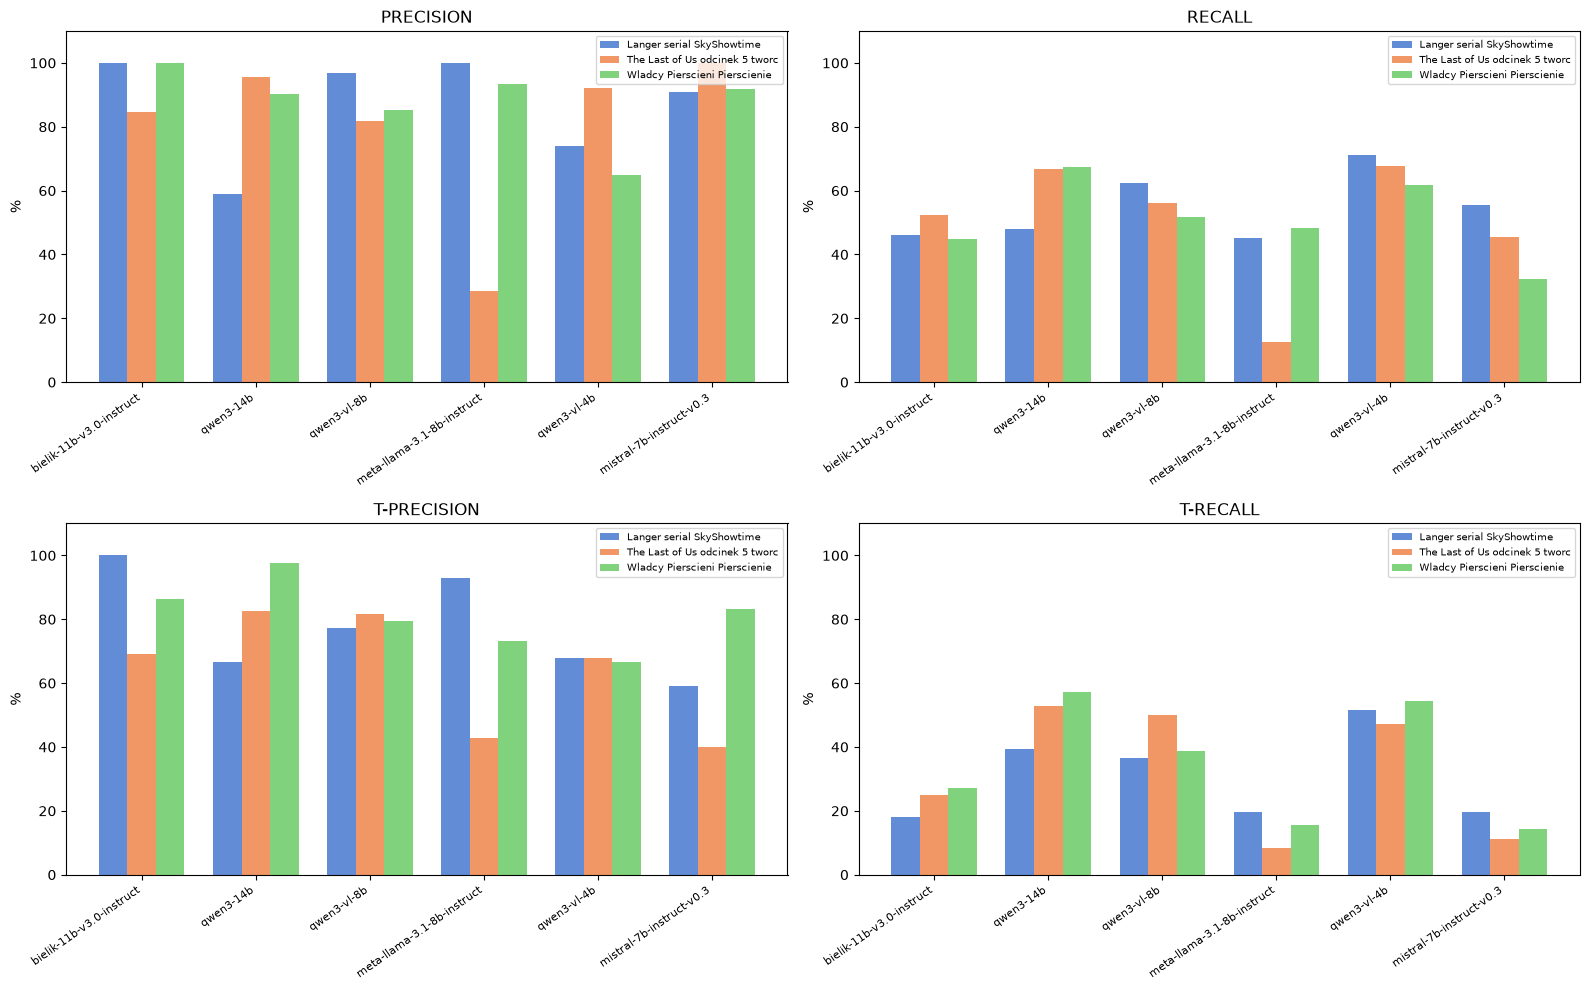

In [6]:
import matplotlib.pyplot as plt
import numpy as np

model_order = summary.index.tolist()
articles = df["title_short"].unique()
colors = ["#4878d0", "#ee854a", "#6acc65"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, ["precision", "recall", "t_precision", "t_recall"]):
    pivot = df.pivot_table(index="model_short", columns="title_short", values=metric).reindex(model_order) * 100
    x = np.arange(len(model_order))
    w = 0.25
    for i, (art, color) in enumerate(zip(pivot.columns, colors)):
        ax.bar(x + (i - 1) * w, pivot[art], w, label=art[:30], color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 110)
    ax.set_ylabel("%")
    ax.set_title(metric.replace("_", "-").upper())
    ax.legend(fontsize=7)

# fig.suptitle("Etap 1 — Small Models, Default Prompt", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

 Wnioski:

  1. qwen3-14b — najlepszy balans. Najwyższy T-Recall (0.498) i bardzo wysokie T-Precision (0.823), co daje najlepsze T-F1. Dobrze rozumie semantykę relacji.
  2. bielik-11b — najwyższa Precision i T-Precision, ale bardzo niski Recall/T-Recall (0.234). Ekstraktoruje mało relacji, ale te które wyciąga — są trafne. Konserwatywny model.
  3. qwen3-vl-8b — solidny środek, dobry balans bez skrajności.
  4. qwen3-vl-4b — zaskakująco wysoki Recall (0.668) jak na 4B model, ale T-Precision tylko 0.676 — dużo halucynacji semantycznych.
  5. mistral-7b i meta-llama — najsłabsze T-Recall (~0.15), praktycznie nie trafiają w semantykę relacji referencyjnych.